In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cargar datos
daily = pd.read_csv("../data/raw/eurusd_daily.csv", header=[0,1], index_col=0, parse_dates=True)
h4 = pd.read_csv("../data/raw/eurusd_4h.csv", header=[0,1], index_col=0, parse_dates=True)

print(f"Daily: {daily.shape} | De {daily.index[0].date()} a {daily.index[-1].date()}")
print(f"4H:    {h4.shape} | De {h4.index[0].date()} a {h4.index[-1].date()}")
print("\nColumnas Daily:")
print(daily.columns.tolist())

Daily: (4231, 5) | De 2010-01-01 a 2026-04-03
4H:    (352, 5) | De 2026-01-12 a 2026-04-03

Columnas Daily:
[('Close', 'EURUSD=X'), ('High', 'EURUSD=X'), ('Low', 'EURUSD=X'), ('Open', 'EURUSD=X'), ('Volume', 'EURUSD=X')]


In [3]:
# Simplificar columnas
daily.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
h4.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Verificar
print("Daily — primeras filas:")
print(daily.head(3))
print("\n4H — primeras filas:")
print(h4.head(3))

Daily — primeras filas:
               Close      High       Low      Open  Volume
Date                                                      
2010-01-01  1.438994  1.440196  1.432706  1.432706       0
2010-01-04  1.442398  1.445191  1.426208  1.431004       0
2010-01-05  1.436596  1.448310  1.435194  1.442710       0

4H — primeras filas:
                              Close      High       Low      Open  Volume
Datetime                                                                 
2026-01-12 00:00:00+00:00  1.165909  1.167406  1.162656  1.162791       0
2026-01-12 04:00:00+00:00  1.168907  1.168907  1.165637  1.165909       0
2026-01-12 08:00:00+00:00  1.168224  1.169864  1.167951  1.168770       0


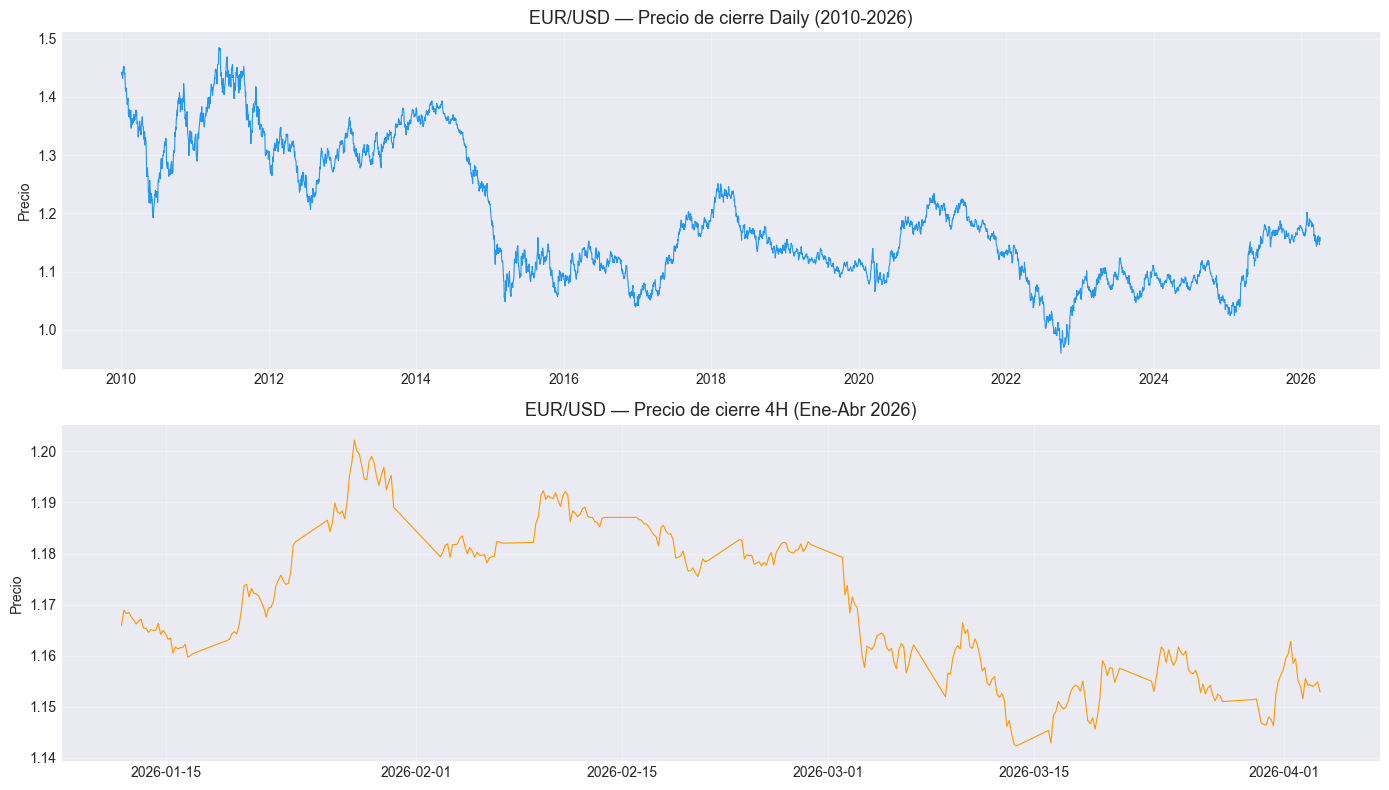

Gráfica guardada.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfica Daily7
axes[0].plot(daily.index, daily['Close'], color='#2196F3', linewidth=0.8)
axes[0].set_title('EUR/USD — Precio de cierre Daily (2010-2026)', fontsize=13)
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Gráfica 4H
axes[1].plot(h4.index, h4['Close'], color='#FF9800', linewidth=0.8)
axes[1].set_title('EUR/USD — Precio de cierre 4H (Ene-Abr 2026)', fontsize=13)
axes[1].set_ylabel('Precio')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/01_precio_historico.png', dpi=150)
plt.show()
print("Gráfica guardada.")

In [5]:
# Calcular retornos logarítmicos
daily['returns'] = np.log(daily['Close'] / daily['Close'].shift(1))
h4['returns'] = np.log(h4['Close'] / h4['Close'].shift(1))

# Eliminar el primer NaN
daily = daily.dropna()
h4 = h4.dropna()

print("Estadísticas de retornos Daily:")
print(daily['returns'].describe().round(6))
print(f"\nSkewness: {daily['returns'].skew():.4f}")
print(f"Kurtosis: {daily['returns'].kurtosis():.4f}")

Estadísticas de retornos Daily:
count    4230.000000
mean       -0.000052
std         0.005342
min        -0.028144
25%        -0.003022
50%        -0.000048
75%         0.002934
max         0.031262
Name: returns, dtype: float64

Skewness: -0.0364
Kurtosis: 2.2926


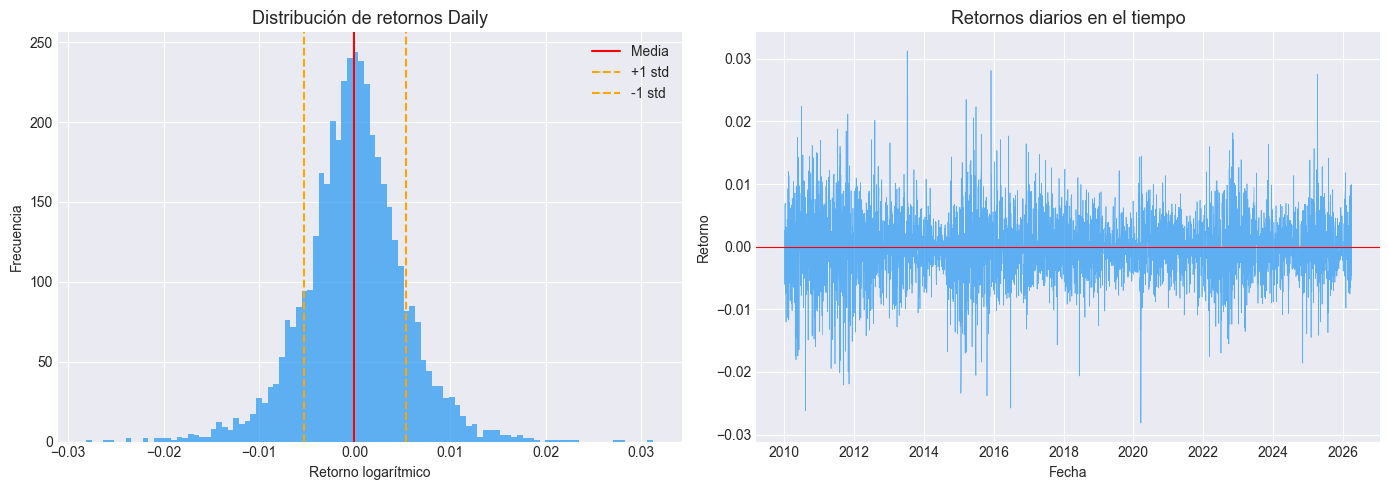

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de retornos
axes[0].hist(daily['returns'], bins=100, color='#2196F3', alpha=0.7, edgecolor='none')
axes[0].axvline(daily['returns'].mean(), color='red', linewidth=1.5, label='Media')
axes[0].axvline(daily['returns'].std(), color='orange', linewidth=1.5, linestyle='--', label='+1 std')
axes[0].axvline(-daily['returns'].std(), color='orange', linewidth=1.5, linestyle='--', label='-1 std')
axes[0].set_title('Distribución de retornos Daily', fontsize=13)
axes[0].set_xlabel('Retorno logarítmico')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Retornos en el tiempo
axes[1].plot(daily.index, daily['returns'], color='#2196F3', linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='red', linewidth=0.8)
axes[1].set_title('Retornos diarios en el tiempo', fontsize=13)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno')

plt.tight_layout()
plt.savefig('../data/processed/02_retornos.png', dpi=150)
plt.show()

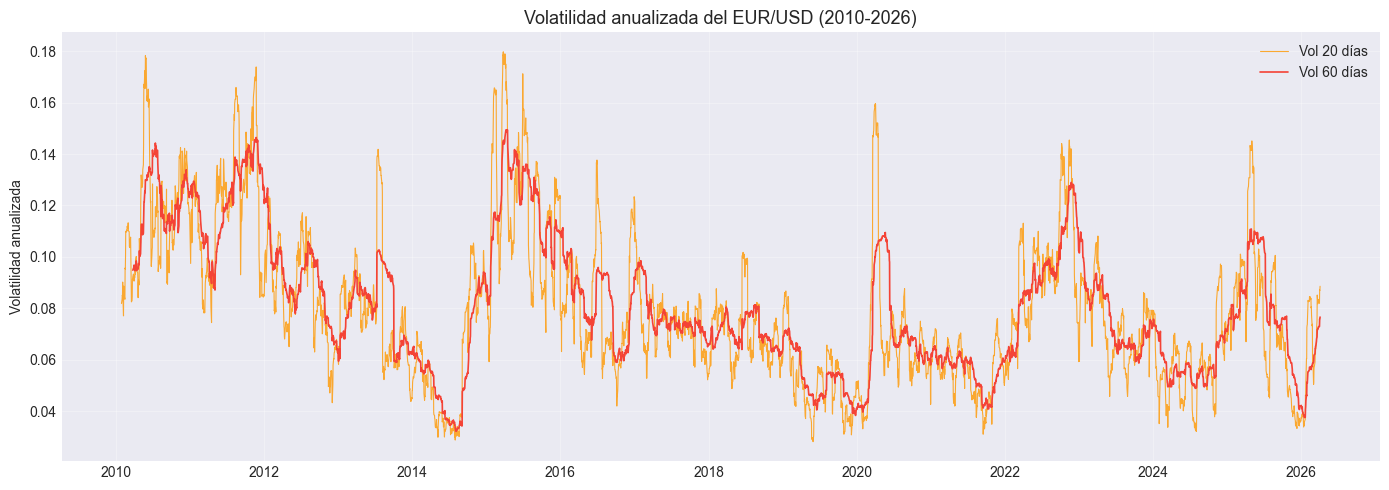

Volatilidad promedio anualizada: 7.98%
Volatilidad máxima: 17.98%
Volatilidad mínima: 2.81%


In [8]:
# Volatilidad rodante 20 días
daily['volatility_20'] = daily['returns'].rolling(20).std() * np.sqrt(252)
daily['volatility_60'] = daily['returns'].rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily['volatility_20'], color='#FF9800', linewidth=0.8, label='Vol 20 días', alpha=0.8)
ax.plot(daily.index, daily['volatility_60'], color='#F44336', linewidth=1.2, label='Vol 60 días')
ax.set_title('Volatilidad anualizada del EUR/USD (2010-2026)', fontsize=13)
ax.set_ylabel('Volatilidad anualizada')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/03_volatilidad.png', dpi=150)
plt.show()

print(f"Volatilidad promedio anualizada: {daily['volatility_20'].mean():.2%}")
print(f"Volatilidad máxima: {daily['volatility_20'].max():.2%}")
print(f"Volatilidad mínima: {daily['volatility_20'].min():.2%}")


In [9]:
# Detección de anomalías — retornos extremos
umbral = daily['returns'].std() * 3
anomalias = daily[np.abs(daily['returns']) > umbral]

print(f"Retornos extremos (>3 std): {len(anomalias)} días")
print(f"Representan el {len(anomalias)/len(daily)*100:.2f}% de los datos")
print("\nLos 10 movimientos más extremos:")
print(daily['returns'].abs().nlargest(10).round(4))


Retornos extremos (>3 std): 51 días
Representan el 1.21% de los datos

Los 10 movimientos más extremos:
Date
2013-07-11    0.0313
2015-12-04    0.0281
2020-03-20    0.0281
2025-04-11    0.0275
2010-08-12    0.0262
2016-06-27    0.0258
2015-10-23    0.0238
2015-03-19    0.0235
2015-01-23    0.0234
2010-07-01    0.0224
Name: returns, dtype: float64


In [10]:
# Guardar datos procesados con retornos y volatilidad
daily.to_csv("../data/processed/eurusd_daily_procesado.csv")

print("EDA completado. Resumen:")
print(f"  Velas analizadas: {len(daily)}")
print(f"  Retorno medio diario: {daily['returns'].mean():.6f}")
print(f"  Volatilidad anualizada promedio: {daily['volatility_20'].mean():.2%}")
print(f"  Días extremos (>3std): {len(anomalias)} ({len(anomalias)/len(daily)*100:.2f}%)")
print(f"  Regímenes visibles: al menos 3 (baja, media, alta volatilidad)")

EDA completado. Resumen:
  Velas analizadas: 4230
  Retorno medio diario: -0.000052
  Volatilidad anualizada promedio: 7.98%
  Días extremos (>3std): 51 (1.21%)
  Regímenes visibles: al menos 3 (baja, media, alta volatilidad)
